# TechMind — Notebook de Ciencia de Datos
### Clasificación temática de contenido técnico + extracción de palabras clave

**Objetivo:** dado un `titulo` y un `texto`, el modelo debe devolver:
- `categoria`: la temática predicha (Backend, Frontend, Data Science, DevOps, Mobile, Bases de Datos, Seguridad, Cloud)
- `probabilidad`: confianza de la predicción
- `informaciones_adicionales`: palabras clave relevantes extraídas del propio texto

Este notebook cubre las entregas obligatorias de Ciencia de Datos pedidas en la consigna:
EDA → preprocesamiento → vectorización TF-IDF → entrenamiento (Regresión Logística) →
evaluación → extracción de keywords → serialización con `joblib`.


## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import re
import string
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)


In [2]:
import os
import psycopg2
from dotenv import load_dotenv

load_dotenv()  # carga .env con las credenciales de PostgreSQL

# ── Conexión a PostgreSQL ─────────────────────────────────────────────────────
con = psycopg2.connect(
    host=os.getenv("PG_HOST", "localhost"),
    port=int(os.getenv("PG_PORT", 5432)),
    dbname=os.getenv("PG_DB", "techmind"),
    user=os.getenv("PG_USER", "techmind_user"),
    password=os.getenv("PG_PASSWORD", "techmind_pass"),
)
print("📡 Conectado a PostgreSQL")

df = pd.read_sql_query("SELECT id, titulo, texto, categoria FROM contenidos", con)
con.close()

print(f"✅ Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
df.head()


(61, 3)


,titulo,texto,categoria
0,Introducción a Spring Boot,En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot.,Backend
1,Arquitectura de microservicios,"Se describen los principios de diseño de microservicios, comunicación entre servicios y patrones como API Gateway y ...",Backend
2,Consultas avanzadas en SQL,"Tutorial sobre subconsultas, joins y funciones de ventana en SQL para consultas complejas.",Bases de Datos
3,Pipelines de Scikit-Learn,Se explica cómo construir pipelines reproducibles que encadenan preprocesamiento y modelado en Scikit-Learn.,Data Science
4,Hooks de React explicados,"Se explican los hooks useState, useEffect y useContext para manejar estado y ciclo de vida en componentes React.",Frontend


**Nota sobre el dataset:** este CSV (`contenidos_tecnicos.csv`) es un dataset sintético de
ejemplo con ~60 registros repartidos en 8 categorías técnicas, pensado para dejar el pipeline
completo funcionando de punta a punta. Para el MVP real del hackathon conviene **ampliarlo**
sumando contenidos propios: descripciones de documentación oficial, resúmenes de cursos,
artículos técnicos (Medium, Baeldung, dev.to, documentación de frameworks), etc. Cuantos más
ejemplos por categoría, mejor generalizará el modelo — con 60 filas el modelo funciona pero
tiene poco margen frente a textos muy distintos a los de entrenamiento.

## 2. Análisis exploratorio de datos (EDA)

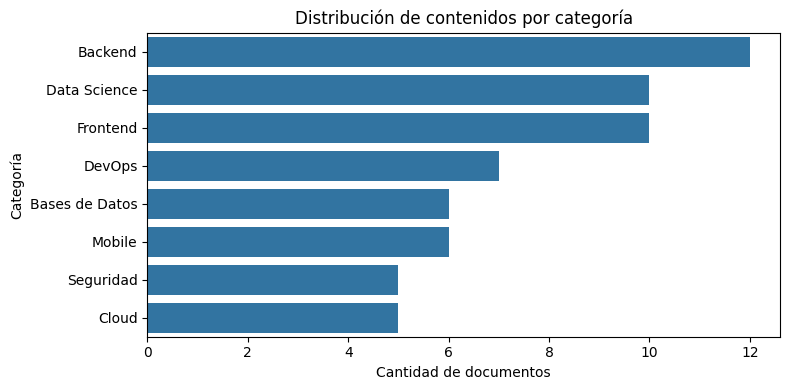

In [3]:
# Distribución de categorías
plt.figure(figsize=(8, 4))
sns.countplot(data=df, y="categoria", order=df["categoria"].value_counts().index)
plt.title("Distribución de contenidos por categoría")
plt.xlabel("Cantidad de documentos")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()


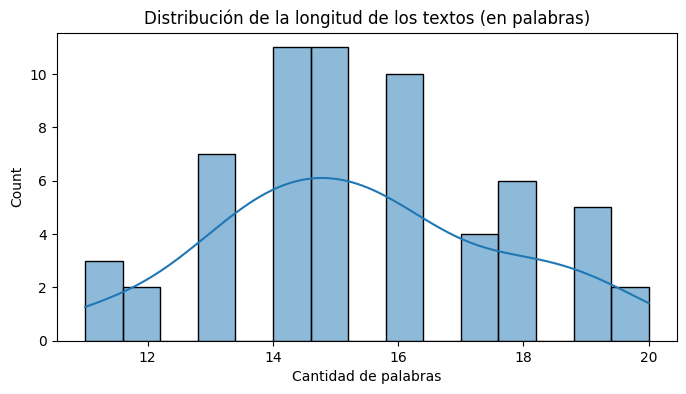

count    61.000000
mean     15.377049
std       2.259527
min      11.000000
25%      14.000000
50%      15.000000
75%      17.000000
max      20.000000
Name: longitud_texto, dtype: float64

In [4]:
# Longitud de los textos (en palabras)
df["longitud_texto"] = df["texto"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(df["longitud_texto"], bins=15, kde=True)
plt.title("Distribución de la longitud de los textos (en palabras)")
plt.xlabel("Cantidad de palabras")
plt.show()

df["longitud_texto"].describe()


In [5]:
# ¿Hay valores nulos o duplicados?
print("Nulos por columna:\n", df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated(subset=["titulo", "texto"]).sum())


Nulos por columna:
 titulo            0
texto             0
categoria         0
longitud_texto    0
dtype: int64

Filas duplicadas: 0


## 3. Preprocesamiento de texto

Combinamos `titulo` + `texto` en un solo campo (el título suele traer términos muy
discriminantes) y aplicamos una limpieza básica: minúsculas, remoción de puntuación y de
stopwords en español.

In [6]:
STOPWORDS_ES = {
    "el","la","los","las","un","una","unos","unas","de","del","al","a","en","y","o",
    "que","con","para","por","se","su","sus","es","son","este","esta","estos","estas",
    "como","más","mas","muy","entre","sobre","desde","hasta","tambien","también","ser",
    "utilizando","utiliza","permite","se explican","se explica","se presenta","se presentan",
    "contenido","introduccion","introducción","tutorial","cómo","como","así","asi",
}

def limpiar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü0-9\s]", " ", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in STOPWORDS_ES and len(p) > 2]
    return " ".join(palabras)

df["texto_completo"] = df["titulo"] + ". " + df["texto"]
df["texto_limpio"] = df["texto_completo"].apply(limpiar_texto)
df[["titulo", "texto_limpio"]].head()


,titulo,texto_limpio
0,Introducción a Spring Boot,spring boot presentan conceptos básicos creación apis rest java spring boot
1,Arquitectura de microservicios,arquitectura microservicios describen principios diseño microservicios comunicación servicios patrones api gateway s...
2,Consultas avanzadas en SQL,consultas avanzadas sql subconsultas joins funciones ventana sql consultas complejas
3,Pipelines de Scikit-Learn,pipelines scikit learn explica construir pipelines reproducibles encadenan preprocesamiento modelado scikit learn
4,Hooks de React explicados,hooks react explicados explican hooks usestate useeffect usecontext manejar estado ciclo vida componentes react


## 4. Vectorización TF-IDF

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1, 2),   # unigramas y bigramas: captura términos como "api rest"
    min_df=1,
)

X = tfidf_vectorizer.fit_transform(df["texto_limpio"])
y = df["categoria"]

print("Matriz TF-IDF:", X.shape)


Matriz TF-IDF: (61, 1013)


## 5. División train/test y entrenamiento del modelo

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## 6. Evaluación del modelo

In [9]:
y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.6875

Reporte de clasificación:

                precision    recall  f1-score   support

       Backend       0.43      1.00      0.60         3
Bases de Datos       0.50      1.00      0.67         1
         Cloud       1.00      1.00      1.00         1
  Data Science       1.00      1.00      1.00         3
        DevOps       0.00      0.00      0.00         2
      Frontend       1.00      0.33      0.50         3
        Mobile       1.00      1.00      1.00         2
     Seguridad       0.00      0.00      0.00         1

      accuracy                           0.69        16
     macro avg       0.62      0.67      0.60        16
  weighted avg       0.67      0.69      0.62        16



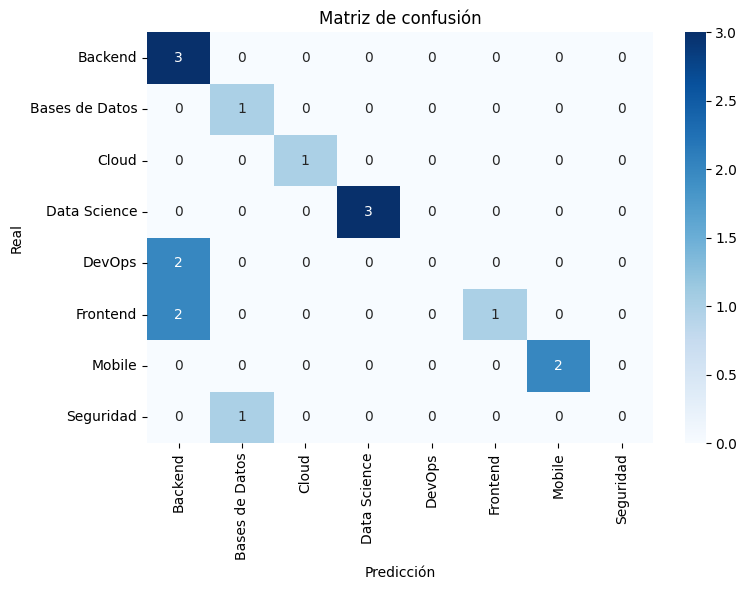

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


**Sobre el dataset pequeño:** con ~60 ejemplos el `test_size` deja pocas muestras por
categoría, así que estas métricas son orientativas. El pipeline (limpieza → TF-IDF →
Regresión Logística → evaluación) es el que importa mantener; al ampliar el dataset real
del equipo, estas mismas celdas ya quedan listas para volver a correr.

## 7. Extracción de palabras clave (`informaciones_adicionales`)

Para las keywords no usamos la predicción del modelo, sino los términos con **mayor peso
TF-IDF dentro del propio documento** (independientemente de la categoría). Esto es lo que en
la consigna se pide como "identificación de palabras clave" y sirve tanto si el documento
está bien clasificado como si no.

In [11]:
def extraer_keywords(texto_limpio: str, vectorizer: TfidfVectorizer, top_n: int = 5):
    """Devuelve las top_n palabras/n-gramas con mayor peso TF-IDF en el documento."""
    vector = vectorizer.transform([texto_limpio])
    feature_names = vectorizer.get_feature_names_out()
    scores = vector.toarray()[0]

    top_indices = scores.argsort()[::-1][:top_n]
    keywords = [feature_names[i] for i in top_indices if scores[i] > 0]
    return keywords

# Prueba rápida
ejemplo = df.iloc[0]
print("Texto:", ejemplo["titulo"])
print("Keywords:", extraer_keywords(ejemplo["texto_limpio"], tfidf_vectorizer))


Texto: Introducción a Spring Boot
Keywords: ['boot', 'spring boot', 'spring', 'creación apis', 'java spring']


## 8. Función de inferencia end-to-end (lo que consumirá el back-end)

In [12]:
def procesar_contenido(titulo: str, texto: str, top_n_keywords: int = 5) -> dict:
    """
    Replica lo que hará el endpoint POST /contenido:
    recibe titulo + texto y devuelve categoria, probabilidad y keywords.
    """
    texto_completo = f"{titulo}. {texto}"
    texto_limpio = limpiar_texto(texto_completo)

    vector = tfidf_vectorizer.transform([texto_limpio])

    categoria_predicha = modelo.predict(vector)[0]
    probabilidades = modelo.predict_proba(vector)[0]
    probabilidad = float(np.max(probabilidades))

    keywords = extraer_keywords(texto_limpio, tfidf_vectorizer, top_n=top_n_keywords)

    return {
        "categoria": categoria_predicha,
        "probabilidad": round(probabilidad, 4),
        "informaciones_adicionales": keywords,
    }

# Ejemplo igual al de la consigna
resultado = procesar_contenido(
    "Introducción a Spring Boot",
    "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."
)
print(json.dumps(resultado, indent=2, ensure_ascii=False))


{
  "categoria": "Backend",
  "probabilidad": 0.2779,
  "informaciones_adicionales": [
    "boot",
    "spring boot",
    "spring",
    "creación apis",
    "java spring"
  ]
}


## 9. Tres ejemplos de uso documentados (requisito del MVP)

In [13]:
ejemplos = [
    {
        "titulo": "Introducción a Spring Boot",
        "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot.",
    },
    {
        "titulo": "Limpieza y transformación de datos",
        "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado.",
    },
    {
        "titulo": "Despliegue de contenedores en producción",
        "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable.",
    },
]

for ej in ejemplos:
    salida = procesar_contenido(ej["titulo"], ej["texto"])
    print("ENTRADA:", json.dumps(ej, ensure_ascii=False))
    print("SALIDA :", json.dumps(salida, ensure_ascii=False))
    print("-" * 80)


ENTRADA: {"titulo": "Introducción a Spring Boot", "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."}
SALIDA : {"categoria": "Backend", "probabilidad": 0.2779, "informaciones_adicionales": ["boot", "spring boot", "spring", "creación apis", "java spring"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Limpieza y transformación de datos", "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado."}
SALIDA : {"categoria": "Data Science", "probabilidad": 0.2007, "informaciones_adicionales": ["datos", "limpieza transformación", "limpieza", "datos uso", "transformación datos"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Despliegue de contenedores en producción", "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable."}
SALIDA : {"categoria": "

## 10. Serialización del modelo

Guardamos el vectorizer y el clasificador por separado (ambos son necesarios en inferencia)
con `joblib`. Estos son los artefactos que el equipo de Back-End va a cargar desde la API
(o desde OCI Object Storage).

In [14]:
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(modelo, "modelo_clasificador.joblib")

print("Modelos guardados: tfidf_vectorizer.joblib, modelo_clasificador.joblib")


Modelos guardados: tfidf_vectorizer.joblib, modelo_clasificador.joblib


In [15]:
# Prueba de carga (simula lo que hará la API al arrancar)
vectorizer_cargado = joblib.load("tfidf_vectorizer.joblib")
modelo_cargado = joblib.load("modelo_clasificador.joblib")

vector_prueba = vectorizer_cargado.transform([limpiar_texto("Introducción a Spring Boot. APIs REST con Java.")])
print("Categoría:", modelo_cargado.predict(vector_prueba)[0])


Categoría: Backend


## 11. Próximos pasos / notas para la integración

- **Subida a OCI Object Storage:** subir `tfidf_vectorizer.joblib` y `modelo_clasificador.joblib`
  al bucket del proyecto; el back-end (Spring Boot) los descarga al iniciar o los sirve un
  microservicio Python (FastAPI/Flask) que exponga `POST /contenido` y sea consumido internamente
  por la API Java, según cómo defina el equipo la arquitectura.
- **Ampliar el dataset:** el dataset actual es sintético (~60 filas) para dejar el pipeline
  funcionando; conviene sumar contenidos reales (documentación, artículos, resúmenes de cursos)
  antes de la demo, sobre todo en las categorías con menos ejemplos.
- **Opcional — recomendación de contenidos relacionados:** con la misma matriz TF-IDF se puede
  calcular similaridad coseno entre documentos (`sklearn.metrics.pairwise.cosine_similarity`)
  para sugerir contenidos parecidos a uno dado.
- **Opcional — búsqueda semántica:** si da tiempo, reemplazar/complementar TF-IDF con embeddings
  (p. ej. `sentence-transformers`) mejora la búsqueda por significado en vez de por palabras exactas.
